In [6]:
# Importing all required libraries for Full EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Visual settings
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 100

print(" All libraries imported successfully!")

 All libraries imported successfully!


In [7]:
# Create output folder for saving all plots
output_folder = "eda_report_output"
os.makedirs(output_folder, exist_ok=True)

# Load Kaggle Titanic dataset (train.csv)
df = pd.read_csv('train.csv')

print("✅ train.csv loaded successfully!")
print(f"\n->Shape : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n->First 5 Rows:")
print(df.head())

✅ train.csv loaded successfully!

->Shape : 891 rows × 12 columns

->First 5 Rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            11380

   Q1: SHAPE & FEATURE TYPES

->Shape             : 891 rows × 12 columns

->Numeric Features  : ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

->Categorical Features: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']

-> Feature Details:
            Data Type  Non-Null Count  Null Count  Null %  Unique Values
PassengerId     int64             891           0    0.00            891
Survived        int64             891           0    0.00              2
Pclass          int64             891           0    0.00              3
Name              str             891           0    0.00            891
Sex               str             891           0    0.00              2
Age           float64             714         177   19.87             88
SibSp           int64             891           0    0.00              7
Parch           int64             891           0    0.00              7
Ticket            str             891           0    0.00            681
Fare     

C:\Users\X280\AppData\Local\Temp\ipykernel_16196\3049748286.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


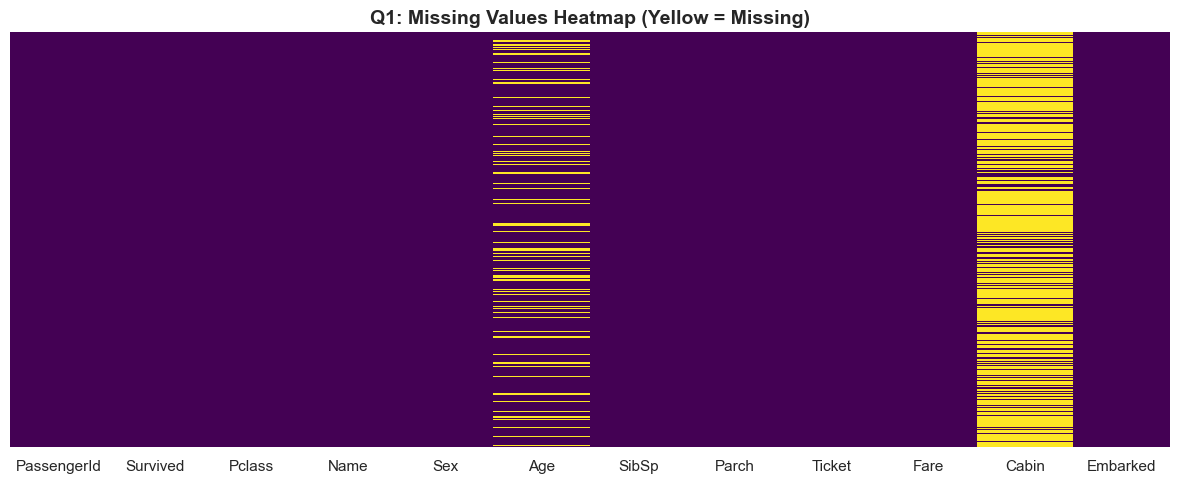

Saved: eda_report_output\01_missing_values_heatmap.png


In [8]:

# QUESTION 1: What is the shape and type of each feature?

print("=" * 55)
print("   Q1: SHAPE & FEATURE TYPES")
print("=" * 55)

# Numeric and Categorical columns identify karo
numeric_cols     = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\n->Shape             : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n->Numeric Features  : {numeric_cols}")
print(f"\n->Categorical Features: {categorical_cols}")

# Detailed feature info table
feature_info = pd.DataFrame({
    'Data Type'     : df.dtypes,
    'Non-Null Count': df.notnull().sum(),
    'Null Count'    : df.isnull().sum(),
    'Null %'        : (df.isnull().sum() / len(df) * 100).round(2),
    'Unique Values' : df.nunique()
})
print(f"\n-> Feature Details:")
print(feature_info)

# Plot: Missing Values Heatmap
plt.figure(figsize=(12, 5))
sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis',
    yticklabels=False
)
plt.title('Q1: Missing Values Heatmap (Yellow = Missing)', fontsize=14, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(output_folder, '01_missing_values_heatmap.png')
plt.savefig(save_path, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")

   Q2: TARGET DISTRIBUTION — 'Survived'

  Not Survived (0) : 549  (61.6%)
  Survived     (1) : 342  (38.4%)


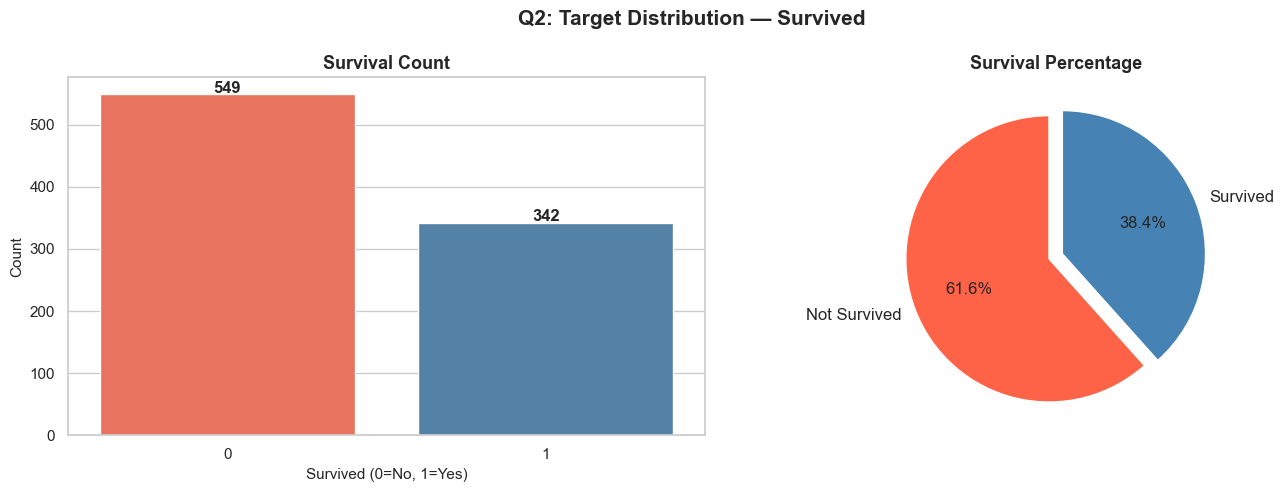

Saved: eda_report_output\02_target_distribution.png


In [9]:

# QUESTION 2: What does the target distribution look like?
# Target = 'Survived' (0 = No, 1 = Yes)

print("=" * 55)
print("   Q2: TARGET DISTRIBUTION — 'Survived'")
print("=" * 55)

survival_counts = df['Survived'].value_counts()
survival_pct    = df['Survived'].value_counts(normalize=True) * 100

print(f"\n  Not Survived (0) : {survival_counts[0]}  ({survival_pct[0]:.1f}%)")
print(f"  Survived     (1) : {survival_counts[1]}  ({survival_pct[1]:.1f}%)")

# Plot: Countplot + Pie Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Countplot
sns.countplot(
    x='Survived', data=df,
    palette={0: 'tomato', 1: 'steelblue'},
    hue='Survived', legend=False,
    ax=axes[0]
)
axes[0].set_title('Survival Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Survived (0=No, 1=Yes)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        str(int(bar.get_height())),
        ha='center', fontsize=12, fontweight='bold'
    )

# Right: Pie Chart
axes[1].pie(
    survival_counts,
    labels=['Not Survived', 'Survived'],
    autopct='%1.1f%%',
    colors=['tomato', 'steelblue'],
    startangle=90,
    explode=(0.05, 0.05),
    textprops={'fontsize': 12}
)
axes[1].set_title('Survival Percentage', fontsize=13, fontweight='bold')

plt.suptitle('Q2: Target Distribution — Survived', fontsize=15, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(output_folder, '02_target_distribution.png')
plt.savefig(save_path, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")

   Q3: FEATURE CORRELATION WITH TARGET

-> Correlation with 'Survived':
Pclass        -0.3385
Age           -0.0772
SibSp         -0.0353
PassengerId   -0.0050
Parch          0.0816
Fare           0.2573
Name: Survived, dtype: float64


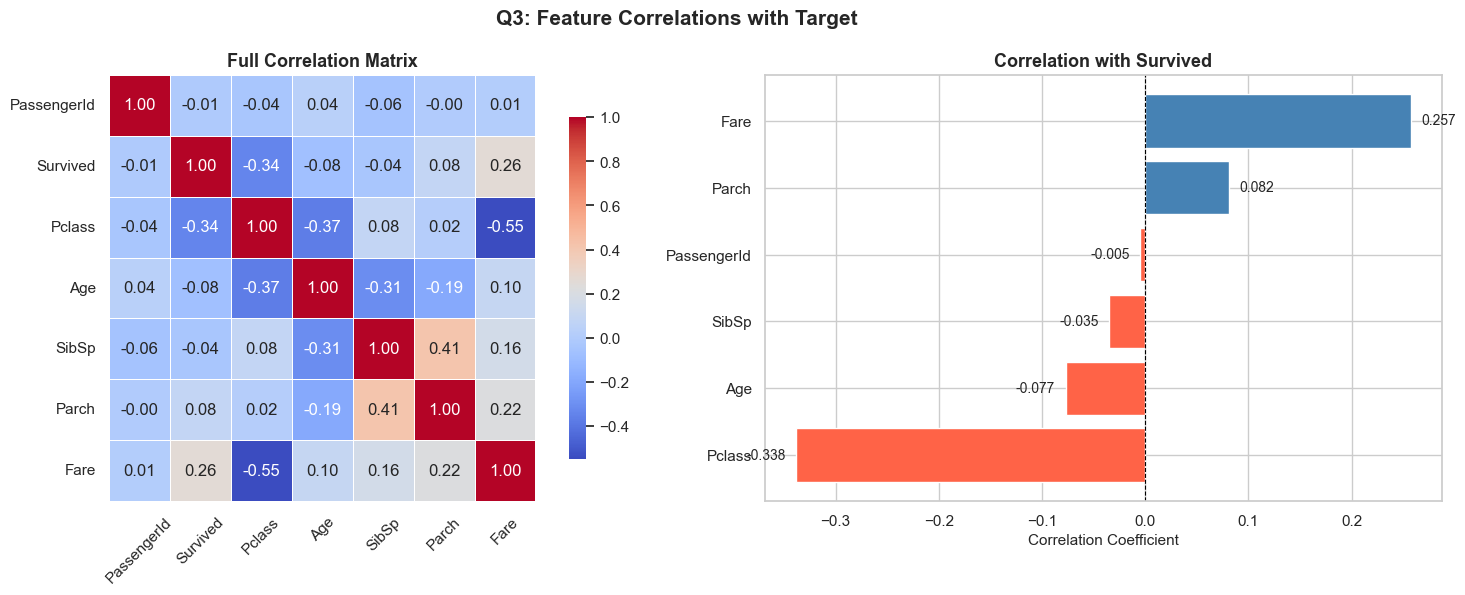

Saved: eda_report_output\03_feature_correlation.png


In [10]:

# QUESTION 3: Which features correlate most with target?

print("=" * 55)
print("   Q3: FEATURE CORRELATION WITH TARGET")
print("=" * 55)

# Numeric correlation with Survived
corr_matrix      = df[numeric_cols].corr()
corr_with_target = corr_matrix['Survived'].drop('Survived').sort_values()

print("\n-> Correlation with 'Survived':")
print(corr_with_target.round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Full Heatmap
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    square=True,
    ax=axes[0],
    cbar_kws={'shrink': 0.8}
)
axes[0].set_title('Full Correlation Matrix', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Right: Bar chart — correlation with target
colors = ['tomato' if x < 0 else 'steelblue' for x in corr_with_target]
axes[1].barh(corr_with_target.index, corr_with_target.values, color=colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Correlation with Survived', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Correlation Coefficient', fontsize=11)
for i, (val, name) in enumerate(zip(corr_with_target.values, corr_with_target.index)):
    axes[1].text(
        val + 0.01 if val >= 0 else val - 0.01,
        i, f'{val:.3f}',
        va='center', fontsize=10,
        ha='left' if val >= 0 else 'right'
    )

plt.suptitle('Q3: Feature Correlations with Target', fontsize=15, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(output_folder, '03_feature_correlation.png')
plt.savefig(save_path, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")

   Q4: OUTLIER DETECTION (IQR Method)

-> Outlier Summary:
Feature  Lower Bound  Upper Bound  Outliers  Outlier %
    Age        -6.69        64.81        11       1.54
   Fare       -26.72        65.63       116      13.02
  SibSp        -1.50         2.50        46       5.16
  Parch         0.00         0.00       213      23.91


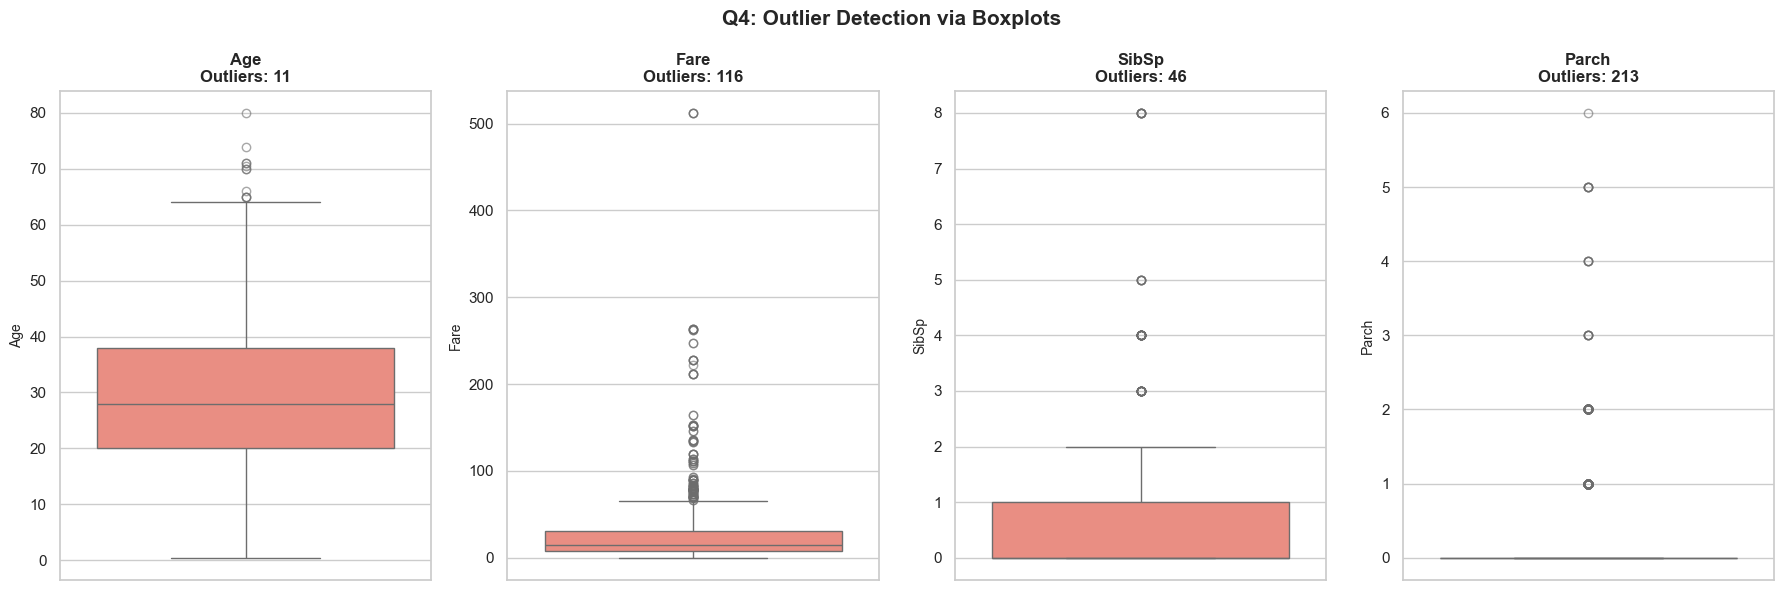

Saved: eda_report_output\04_outlier_detection.png


In [12]:

# QUESTION 4: Are there outliers?
# IQR Method use karenge — most reliable way

print("=" * 55)
print("   Q4: OUTLIER DETECTION (IQR Method)")
print("=" * 55)

# Columns to check for outliers (skip binary/id columns)
outlier_cols = ['Age', 'Fare', 'SibSp', 'Parch']
outlier_summary = []

for col in outlier_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower      = Q1 - 1.5 * IQR
    upper      = Q3 + 1.5 * IQR
    n_outliers = df[(df[col] < lower) | (df[col] > upper)][col].count()
    outlier_pct = round(n_outliers / df[col].count() * 100, 2)
    outlier_summary.append({
        'Feature'    : col,
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2),
        'Outliers'   : n_outliers,
        'Outlier %'  : outlier_pct
    })

outlier_df = pd.DataFrame(outlier_summary)
print("\n-> Outlier Summary:")
print(outlier_df.to_string(index=False))

# Boxplots
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

for i, col in enumerate(outlier_cols):
    sns.boxplot(
        y=df[col].dropna(),
        ax=axes[i],
        color='salmon',
        flierprops=dict(marker='o', color='red', markersize=6, alpha=0.6)
    )
    n_out = outlier_df[outlier_df['Feature'] == col]['Outliers'].values[0]
    axes[i].set_title(f'{col}\nOutliers: {n_out}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel(col, fontsize=10)

plt.suptitle('Q4: Outlier Detection via Boxplots', fontsize=15, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(output_folder, '04_outlier_detection.png')
plt.savefig(save_path, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")

   Q5: CLASS IMBALANCE ANALYSIS


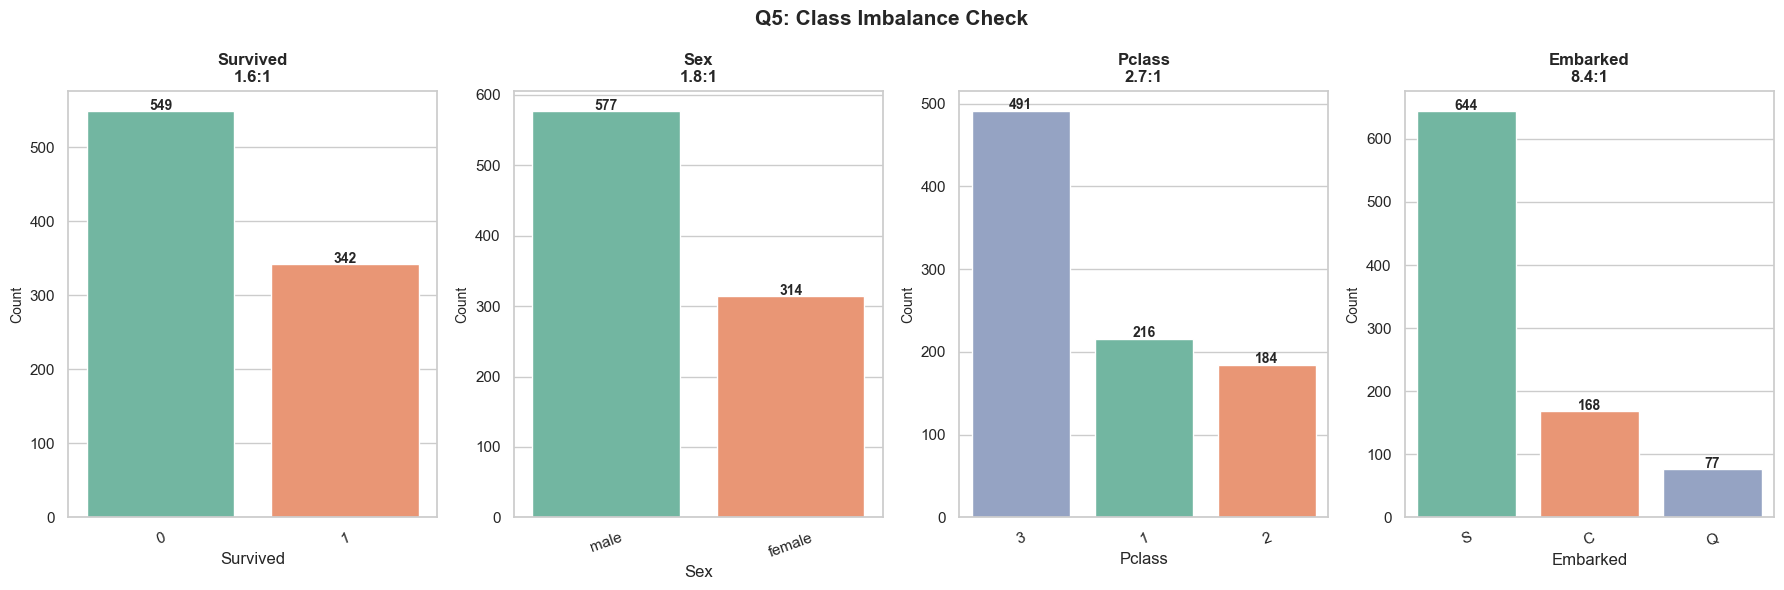

Saved: eda_report_output\05_class_imbalance.png


In [14]:

# QUESTION 5: Are there class imbalances?
# Target + key categorical columns check karenge

print("=" * 55)
print("   Q5: CLASS IMBALANCE ANALYSIS")
print("=" * 55)

cat_cols_check = ['Survived', 'Sex', 'Pclass', 'Embarked']

fig, axes = plt.subplots(1, 4, figsize=(18, 6))

for i, col in enumerate(cat_cols_check):
    val_counts = df[col].value_counts()
    ratio      = val_counts.iloc[0] / val_counts.iloc[-1]
    label      = f"{ratio:.1f}:1" if ratio > 1.5 else f" {ratio:.1f}:1"

    sns.countplot(
        x=col, data=df,
        ax=axes[i],
        hue=col, legend=False,
        palette='Set2',
        order=val_counts.index
    )
    axes[i].set_title(f'{col}\n{label}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Count', fontsize=10)
    axes[i].tick_params(axis='x', rotation=20)

    # Count labels on bars
    for bar in axes[i].patches:
        h = int(bar.get_height())
        if h > 0:
            axes[i].text(
                bar.get_x() + bar.get_width() / 2,
                h + 2, str(h),
                ha='center', fontsize=10, fontweight='bold'
            )

plt.suptitle('Q5: Class Imbalance Check', fontsize=15, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(output_folder, '05_class_imbalance.png')
plt.savefig(save_path, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")

In [17]:
# ─────────────────────────────────────────────────────
# FINAL: Text summary of all EDA findings
# ─────────────────────────────────────────────────────

summary = """
╔══════════════════════════════════════════════════════╗
║       FULL EDA REPORT — TITANIC (Kaggle)          ║
║              INSIGHTS SUMMARY                        ║
╚══════════════════════════════════════════════════════╝

 Q1 — SHAPE & FEATURE TYPES
   • Dataset: 891 rows × 12 columns
   • Numeric   : PassengerId, Survived, Pclass,
                 Age, SibSp, Parch, Fare
   • Categorical: Name, Sex, Ticket, Cabin, Embarked
   • 'Age'   has ~20% missing values (177 nulls)
   • 'Cabin' has ~77% missing — mostly unusable
   • 'Embarked' has only 2 missing values

 Q2 — TARGET DISTRIBUTION
   • 549 passengers (61.6%) did NOT survive
   • 342 passengers (38.4%) survived
   • Mild class imbalance present

 Q3 — FEATURE CORRELATION WITH TARGET
   • 'Fare'   : Positive correlation (+0.26)
                Higher fare = better survival
   • 'Pclass' : Negative correlation (-0.34)
                3rd class passengers survived less
   • 'Age'    : Slight negative (-0.07)
   • 'SibSp'  : Very weak correlation (-0.04)

 Q4 — OUTLIERS
   • 'Fare'  : Significant outliers (some > 500)
   • 'SibSp' : Few high outliers (family > 4)
   • 'Parch' : Minor outliers detected
   • 'Age'   : Mild outliers at higher end (80+)

  Q5 — CLASS IMBALANCE
   • Target  : 61.6% vs 38.4% — mild imbalance
   • Sex     : 65% Male vs 35% Female
   • Pclass  : Class 3 (55%) dominates
   • Embarked: Southampton (72%) dominates

 KEY RECOMMENDATIONS FOR MODELLING
   → Impute 'Age' using median imputation
   → Drop 'Cabin' — too many missing values
   → Cap 'Fare' outliers before training
   → Encode 'Sex' and 'Embarked' (Label/OneHot)
   → Use class_weight='balanced' for imbalance
"""

print(summary)

# Save to text file
summary_path = os.path.join(output_folder, '06_eda_insights_summary.txt')
with open(summary_path, 'w', encoding='utf-8') as f:
    f.write(summary)
print(f" Summary saved: {summary_path}")


╔══════════════════════════════════════════════════════╗
║       FULL EDA REPORT — TITANIC (Kaggle)          ║
║              INSIGHTS SUMMARY                        ║
╚══════════════════════════════════════════════════════╝

 Q1 — SHAPE & FEATURE TYPES
   • Dataset: 891 rows × 12 columns
   • Numeric   : PassengerId, Survived, Pclass,
                 Age, SibSp, Parch, Fare
   • Categorical: Name, Sex, Ticket, Cabin, Embarked
   • 'Age'   has ~20% missing values (177 nulls)
   • 'Cabin' has ~77% missing — mostly unusable
   • 'Embarked' has only 2 missing values

 Q2 — TARGET DISTRIBUTION
   • 549 passengers (61.6%) did NOT survive
   • 342 passengers (38.4%) survived
   • Mild class imbalance present

 Q3 — FEATURE CORRELATION WITH TARGET
   • 'Fare'   : Positive correlation (+0.26)
                Higher fare = better survival
   • 'Pclass' : Negative correlation (-0.34)
                3rd class passengers survived less
   • 'Age'    : Slight negative (-0.07)
   • 'SibSp'  : Very

In [19]:
# List all saved output files
saved_files = sorted(os.listdir(output_folder))

print("=" * 55)
print("      EDA REPORT — ALL SAVED FILES")
print("=" * 55)
for f in saved_files:
    print(f"    {f}")
print("=" * 55)
print(f"\n Full EDA Complete! ({len(saved_files)} files saved)")

      EDA REPORT — ALL SAVED FILES
    01_missing_values_heatmap.png
    02_target_distribution.png
    03_feature_correlation.png
    04_outlier_detection.png
    05_class_imbalance.png
    06_eda_insights_summary.txt

 Full EDA Complete! (6 files saved)
